In [16]:
import os
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
import pandas as pd


os.environ["RUNNING_LOCALLY"] = "True"


In [17]:
from etl.db.connection import Connection
def query_fetch_df(conn:Connection,query_str: str):
    """Run a query and return as a pandas DataFrame."""
    return pd.DataFrame(conn.fetch_all(query_str), columns=[desc.name for desc in conn.cur.description])
#
# with Connection() as conn:
#     bme_data  = query_fetch_df(conn,"SELECT timestamp,temperature,humidity,pressure FROM bme280 ORDER BY timestamp ASC").resample(on='timestamp', rule='10min').mean()
#     ds_data   = query_fetch_df(conn,"SELECT timestamp,temperature FROM ds18b20 ORDER BY timestamp ASC").resample(on='timestamp', rule='10min').mean()
#     jaeg_data = query_fetch_df(conn,"SELECT * FROM dmi WHERE source_id='06181' ORDER BY timestamp ASC").set_index('timestamp')



In [18]:

with Connection() as conn:
    bme_data  = query_fetch_df(conn,"SELECT * FROM bme280_res ORDER BY timestamp ASC").set_index('timestamp')
    ds_data   = query_fetch_df(conn,"SELECT * FROM ds18b20_res ORDER BY timestamp ASC").set_index('timestamp')
    jaeg_data = query_fetch_df(conn,"SELECT * FROM dmi WHERE source_id='06181' ORDER BY timestamp ASC").set_index('timestamp')


In [19]:
def get_time_range(dfs:list,span:timedelta = timedelta(days=1),greedy=False):
    if greedy:
        f1 = min
        f2 = max
    else:
        f1 = max
        f2 = min
    
    t_min = f1([min(df.index) for df in dfs])
    t1 = f2([max(df.index) for df in dfs])
    t0 = t1 - span
    if t0 < t_min:
        print(f"Warning: t0 of {t0} too early, using minimum of {t_min} instead")
        t0 = t_min
    return t0,t1

# def get_time_range_greedy(dfs:list,span:timedelta = timedelta(days=1)):
#     t_min = min([min(df.index) for df in dfs])
#     t1 = max([max(df.index) for df in dfs])

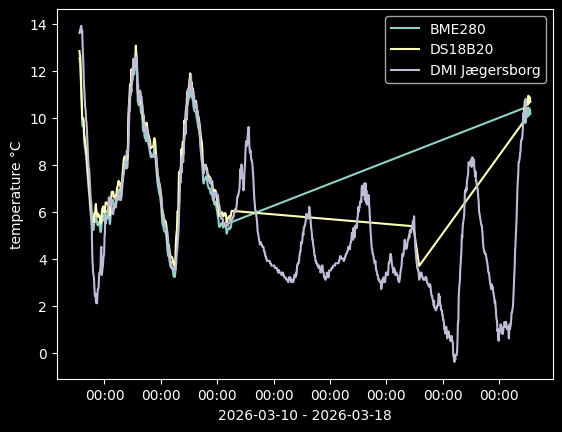

In [32]:


unit_dic = {'temperature':'°C','humidity':'%','pressure':'hPa'}

def plot_param(param, dfs, labels, span=timedelta(days=8), greedy=False):
    fig, ax = plt.subplots()
    t0,t1 = get_time_range(dfs,span,greedy)
    for df,label in zip(dfs,labels):
        series = df.loc[t0:t1]
        ax.plot(series.index,series[param],label=label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend()
    ax.set_ylabel(f"{param} {unit_dic[param]}")

    if t0.day == t1.day:
        ax.set_xlabel(f"{t0:%Y-%m-%d}")
    else:
        ax.set_xlabel(f"{t0:%Y-%m-%d} - {t1:%Y-%m-%d}")

    # ax.set_title(param)
    plt.show()

plot_param('temperature',[bme_data,ds_data,jaeg_data],['BME280','DS18B20','DMI Jægersborg'])

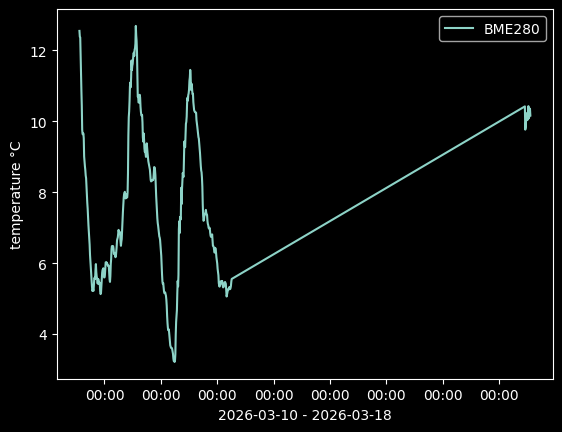

In [33]:
plot_param('temperature',[bme_data],['BME280'],span=timedelta(days=8),greedy=False)

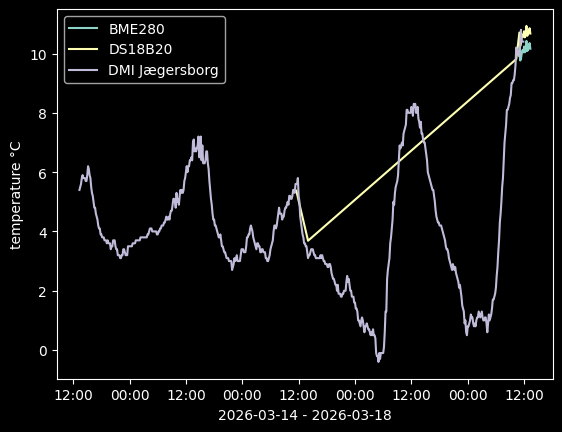

In [21]:
plot_param('temperature',[bme_data,ds_data,jaeg_data],['BME280','DS18B20','DMI Jægersborg'],span=timedelta(days=4),greedy=True)

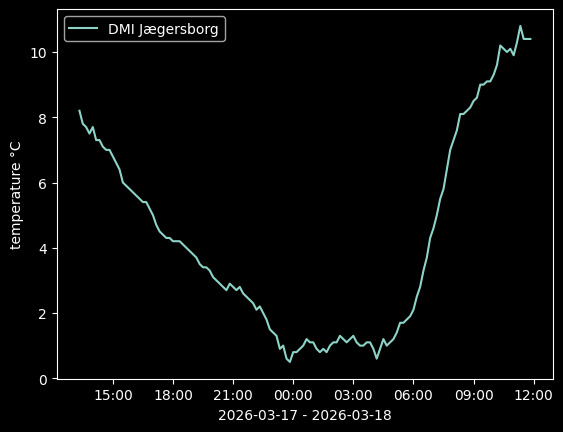

In [22]:
plot_param('temperature',[jaeg_data],['DMI Jægersborg'])

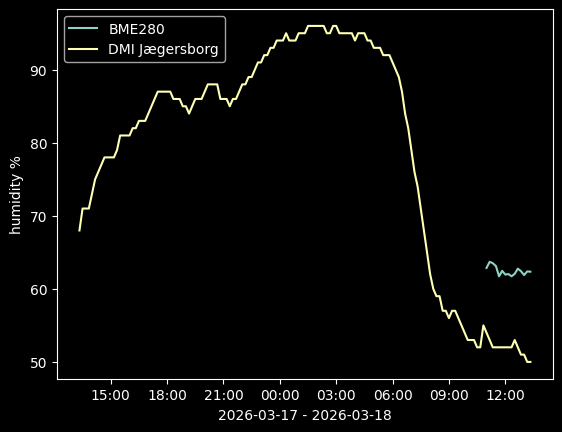

In [31]:
plot_param('humidity',[bme_data,jaeg_data],['BME280','DMI Jægersborg'])

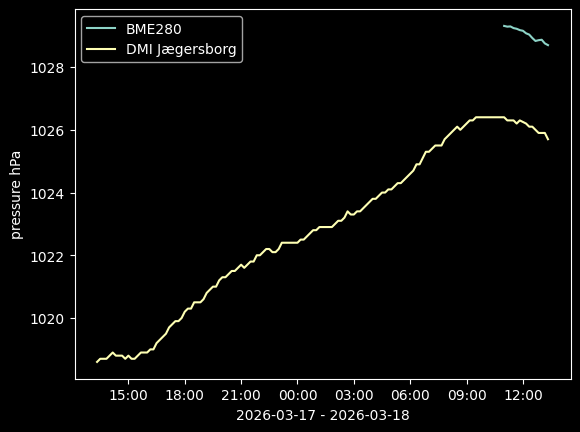

In [24]:
plot_param('pressure',[bme_data,jaeg_data],['BME280','DMI Jægersborg'])

In [25]:
bme_data

,temperature,humidity,pressure
timestamp,,,
2026-03-09 10:20:00+00:00,9.301255,56.406982,1020.163036
2026-03-09 10:30:00+00:00,9.500671,56.039606,1020.082677
2026-03-09 10:40:00+00:00,9.697147,55.987080,1019.956419
2026-03-09 10:50:00+00:00,9.908023,55.751511,1019.811863
2026-03-09 11:00:00+00:00,10.267936,55.371025,1019.732146
...,...,...,...
2026-03-18 12:40:00+00:00,10.082811,62.769766,1028.832961
2026-03-18 12:50:00+00:00,10.120416,62.425470,1028.857131
2026-03-18 13:00:00+00:00,10.228844,61.896839,1028.871579
